<a href="https://colab.research.google.com/github/Arrah28/AWS-ML-Financial-Health-Analytics-Project/blob/main/Unsupervised_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

#Unsupervised Data Summary

---


In [37]:
cc_df = pd.read_csv('/content/CC GENERAL.csv')
print ('Print Databases loaded successfully')

Print Databases loaded successfully


In [38]:
#Categorical distribution
print("\n--- CREDIT CARD CATEGORICAL DATA ---")
print("Total Unique Customers:", cc_df['CUST_ID'].nunique()) #It will only unique and non repetitive cusotmer based on the ID


--- CREDIT CARD CATEGORICAL DATA ---
Total Unique Customers: 8950


In [39]:
print(cc_df.describe().T) #outputs 8 key features

                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE                      8950.0   978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY            8950.0     0.135144     0.200121   0.000000   
CASH_ADVANCE_TRX                  8950.0     3.248827     6.824647   0.000000   
PURCHASES_TRX               

One key difference to note between the supervised and unsupervised datasets is that in the unsupervised we do not have a target column, which is essentially the answer column. Instead for unsupervised we have a range of columns which need to be analysed, corelations need to be found and then clustered (grouped).
Now the output shows us the 8 different numerical characteristics of the dataset.

They key ones for us being that :
* Mean and median together - if the mean is much higher than the Median, this means that there is major outlier or in the context of this dataset, there are big spenders pulling the total average of the dataset up.
* Max and Min -Simply tell us the smallest and most extreme value in our dataset.
* Std - Tells us if customers are mostly similar (low Std) or highly different (high Std).

The reason why these characteristics are crucial is because this dataset our goal is to cluster the data (k means). The model will do this clustering based on mathematical calculation which will calculate the "Distance" between customers and group each customer to its closest cluster.



#In depth:

---

In the dataset if we look the purchase_frequency value the values are within 0 and 1 and the biggest difference within the dataset is approximately 0.5 which is considerably small. What this will result in the models thinking the numerical differences like £100 difference in balance between individuals is 100 times more important than the frequency difference.

So, the data analysis and prediction will not be equal nor fair. The way to overcome this is to scale all the data to 0.

Now, if we look at the median value when it comes to purchases, we see that the:

* 50% only spends £361
* 75% spends £1,110
* One person spent £49,039

The data is very heavily right skewed due to this extremely high figure. Now what will happen is if we don’t scale our data these few big spenders will end up in their own clusters, and the other 8000 people will be lumped into one giant individual cluster which is not what we want at all.

Now, another thing to note is that there is customer data missing. Looking at the count column which gives us a total amount of data within each feature we can see that:

* Most features have 8,950 rows.

* credit limit has 8949 (1 person is missing a limit)

* minimum payments have 8637 (313 people are missing payments)

The reason why this is crucial is because we cannot calculate the distance when it will come to clustering the data if there are holes in customer information so what we will do is SimpleImpute with the median value for those specific numerical features.


In [40]:
# Credit dataset summary
print("--- CREDIT CARD DATASET OVERVIEW ---")
print(f"Instances (Rows): {cc_df.shape[0]}, Features (Columns): {cc_df.shape[1]}")
print("\nMissing Values per Feature:")
print(cc_df.isnull().sum())

--- CREDIT CARD DATASET OVERVIEW ---
Instances (Rows): 8950, Features (Columns): 18

Missing Values per Feature:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64



This is a clearer view of the 313 missing values in minimum payments and the 1 in credit_limit. One key thing to notice is that some features might be repetitive in the sense of their output definition. So what the data tells us for example, PURCHASES and PURCHASES_TRX (which simply refers to Transactions).




In [41]:
#Mean , Mediam and Standard deviations
print("\n--- CREDIT CARD NUMERICAL MEASURES ---")
stats_cc = cc_df[['BALANCE', 'PURCHASES']].agg(['mean', 'median', 'std']) #.agg will join the  data instead of just giving one stat it will give three at once for the columns  selected
print(stats_cc)


--- CREDIT CARD NUMERICAL MEASURES ---
            BALANCE    PURCHASES
mean    1564.474828  1003.204834
median   873.385231   361.280000
std     2081.531879  2136.634782


Identifying these 3 values, the mean, median and std is crucial in unsupervised learning as it will help us find Skewness. If data is skewed, which it is as we have already seen form the outlying big spenders, then centre of our clusters will be pulled toward the extreme outliers.

Now, remembering that the mean is a key value which is easily influenced by outliers. And the median is the most middle value of the numerical in the set.

So:
* BALANCE: The Mean is £1564 which is nearly double the Median of £873

* PURCHASES: The Mean is £1003 is nearly triple the Median of £361

This overall already tells us that the data is very right skewered. As the average spending of a typical (median) customers is £361 but due to the big spenders are resulting in the mean being shown as £1003

Now another final factor is that eh std is extremely large. A high Std relative to the Mean tells us that the data is very mixed and spread out.


##Visualisations: Histogram, Boxplot and Scatter Plot

---



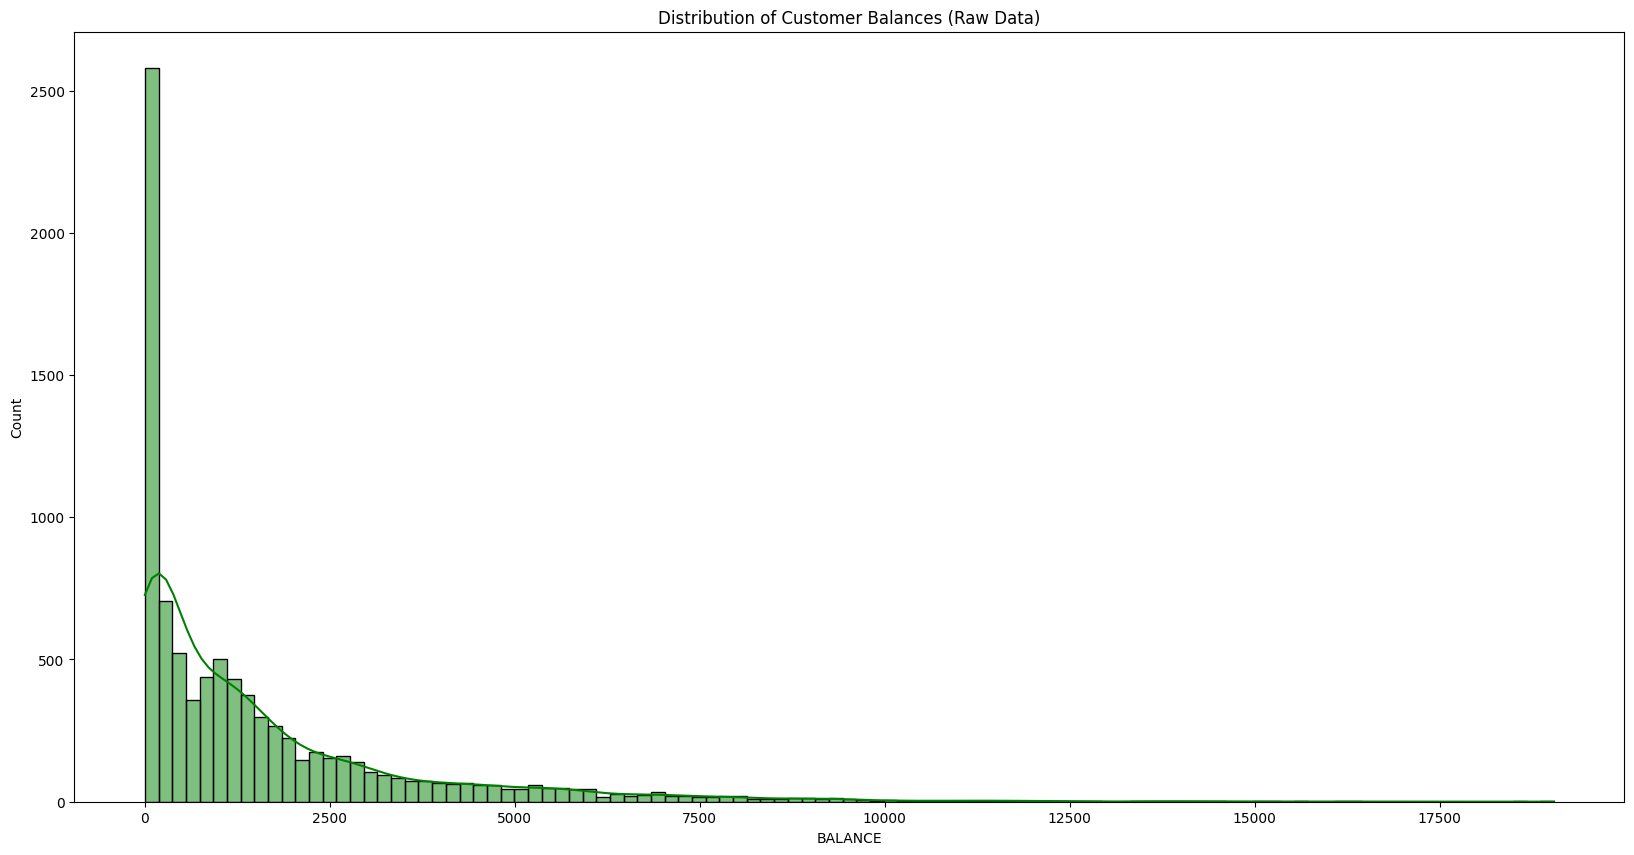

In [42]:
# Histogram used to  Check for "Skewness" in this financial data.
plt.figure(figsize=(20, 10))
sns.histplot(cc_df['BALANCE'], kde=True, color='green')
plt.title('Distribution of Customer Balances (Raw Data)')
plt.show()
#the code above SORTS, BINS, provides a frequency count and the KDE

This histogram is visual proof in relation to customers spending and that they are not all the same, which is exactly why clustering is required.

The Tall bar on the left side represents the vast majority of the 8950 customers who have very low balances which is between £0 and £1000

The Long and same height bars on the right Side that stretch all the way to £19,000. These are your high debt or high usage customers

The Green KDE Line simplifies the visualisation trend of the bars by simplifying the overall "flow"



#In depth :

---
Futher down the development of the model we will use K-Means clustering which for effiency prefers data that is Symmetric making it easier to analyse and group. Currently the data is  stretched out due to the few but large spenderswhich pull the cluster centers far away from the average person

This graph helps us understand why StandardScaler is required as feature like balance which range from 0 to 19,000 will overpower features like Purchases Frequency which only has two values, 0 to 1.

As shown in the grpah he highest bar is right at the beginning covering the vlaues betwen £0-£500. Telling us that tells us that banks primary business is people who use their cards lightly or pay them off quickly within that spending range.

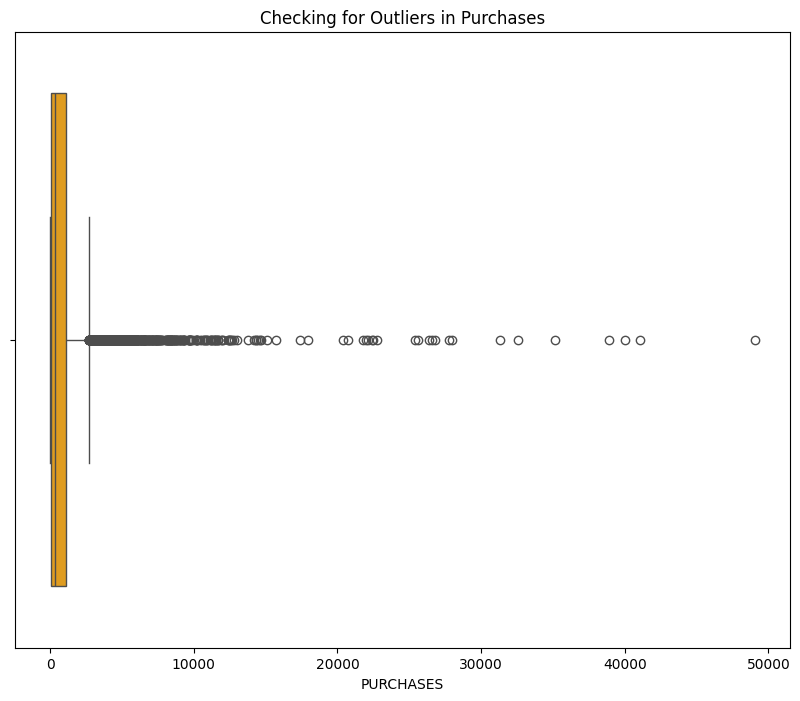

In [43]:
# A boxplot to Check for financial "Outliers" and it will help with the applicaiton explanation of standard scaling later.
plt.figure(figsize=(10, 8))
sns.boxplot(x=cc_df['PURCHASES'], color='orange') #calculates the box height, the difference between the 75th and 25th percentiles
plt.title('Checking for Outliers in Purchases')
plt.show()

So, the histogram showed us the shape of our customers in terms of their spending and differences in that feature. The boxplot identifies the exact outliers, the big spenders which are causing our dataset to be highly right skewed.

The orange box represents the middle 50% of the customers. The box is located very far to the left that this is because most people spend very little, as evident by the median being only £361

The whisker extending to the right, which is attached to the orange box represent the normal spending range.

The row of dots which is outside the right whisker represents all the outliers in the data and its crucial to notice the x-axis goes from 0 to 50,000


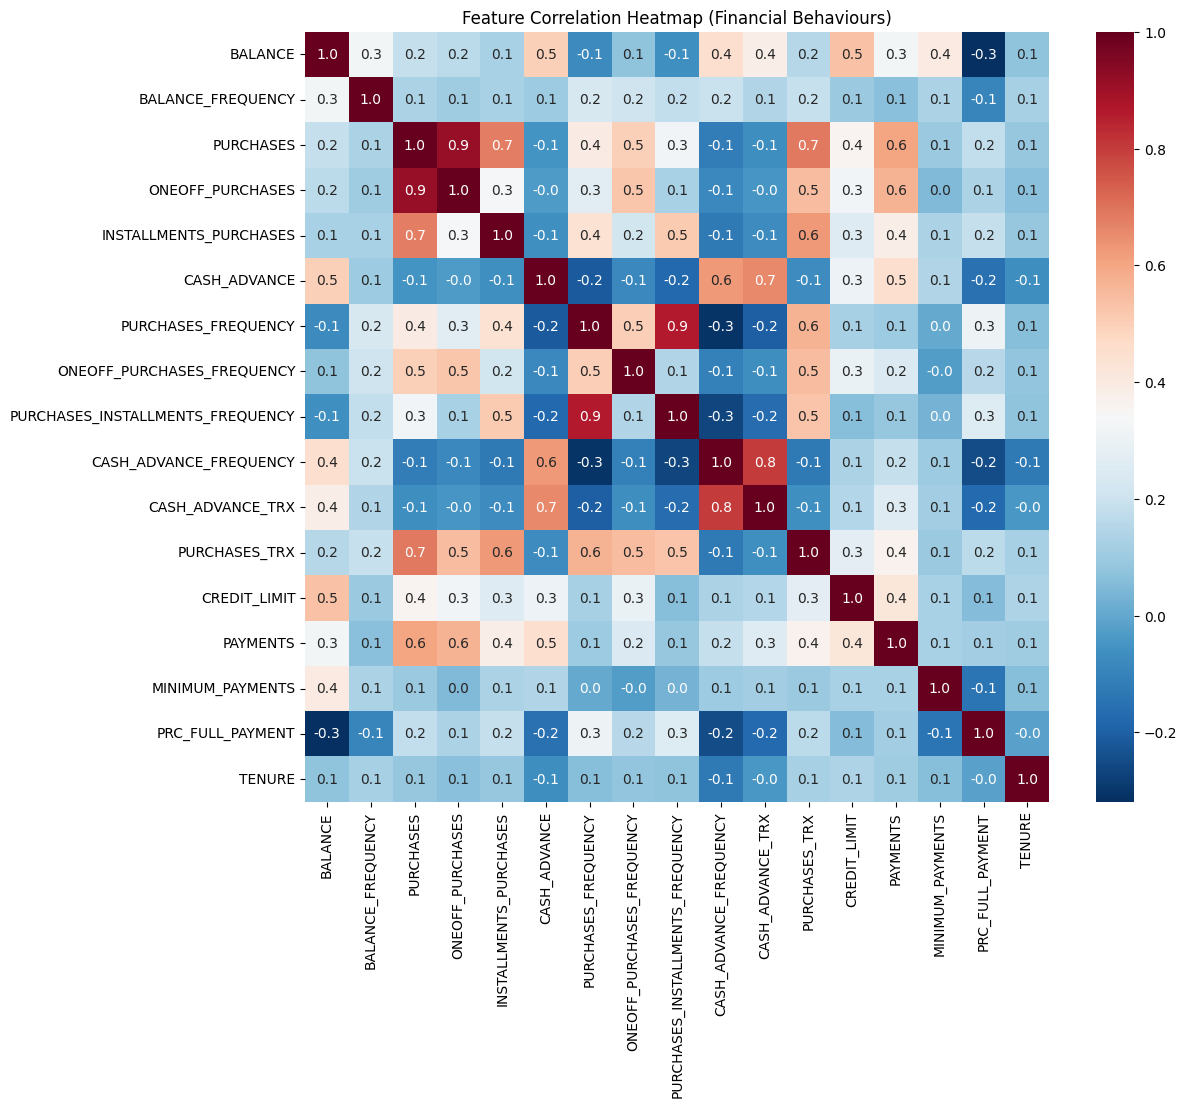

In [44]:
plt.figure(figsize=(12, 10))
# Dropping CUST_ID as it's non-numeric
sns.heatmap(cc_df.drop('CUST_ID', axis=1).corr(), annot=True, fmt=".1f", cmap='RdBu_r')
plt.title('Feature Correlation Heatmap (Financial Behaviours)')
plt.show()

This heatmap is the visual relationship map which helps identify patterns by analysing financial features which go hand in hand and which ones are separate.

The colours:
 * Deep Red - 1.0 - This colour signifies a perfect positive correlation. These features, as one goes up, the other almost always does as well.

* Deep Blue - -1.0 - This colour signifies a perfect negative correlation. These features are opposites so as one goes up, the other goes down.

* White and Light colours - 0.0 - These features no mathematical relationship.

The Number simply give a numerical representation for the strength of the relationship, a 0.9 is extremely strong; a 0.1 is very weak.

Now, the way this heatmap is used when it comes to clustering, so for example CASH_ADVANCE and PURCHASES have a negative and a low correlation, so we can expect to find a cluster of Cash Users and a separate cluster of Shoppers.


#Data Pre-processing

---


In [45]:
#this will fill the missing 'MINIMUM_PAYMENTS' and 'CREDIT_LIMIT' with the mean value
imputer = SimpleImputer(strategy='median')
cc_df['MINIMUM_PAYMENTS'] = imputer.fit_transform(cc_df[['MINIMUM_PAYMENTS']])
cc_df['CREDIT_LIMIT'] = imputer.fit_transform(cc_df[['CREDIT_LIMIT']])

In [46]:
#This will drop the the ID column as its not a behaviour , just extra noise
numeric_cols = cc_df.drop('CUST_ID', axis=1).columns
cc_df[numeric_cols] = cc_df[numeric_cols].clip(upper=cc_df[numeric_cols].quantile(0.95), axis=1)

In [47]:
# Standardise the numerical value so the all hav an average of 0 , making the
# data amore centered and comperable
scaler = StandardScaler()

In [48]:
# Convert back to a DataFrame for easier viewing rahter then leaving it as array
cc_scaled = scaler.fit_transform(cc_df.drop('CUST_ID', axis=1))

In [49]:
print("Variable 'cc_scaled' created successfully!")

Variable 'cc_scaled' created successfully!


To pre-process the data, firstly ensuring all Nan values are filled in we used SimpleImputer, which takes the Median and replaces the 313 missing holes in MINIMUM_PAYMENTS

The reason we done this is because clustering calculates distance and if a customer is missing a value the computer will not be able to do calculations properly.

The reason the median was used is because as identified the features were heavily right skewed. So, if the Mean was used then the big spenders would pull that average up.

Now. quantile 0.95 and. clip was essential to find the value for 95% of people and anyone below this percentile is rounded to the limit. Now, the reason we done this is because the K-Means model will create one cluster just for one person who spent £49,000 and put the other 8949 people into one giant individual cluster.

Now, to ensure all data is viewed equally and no favouritism is shown we used StandardScaler. This function transformed every column, so the average is 0 and the spread is 1 for all the numerical values.



#Hierarchical Clustering

---



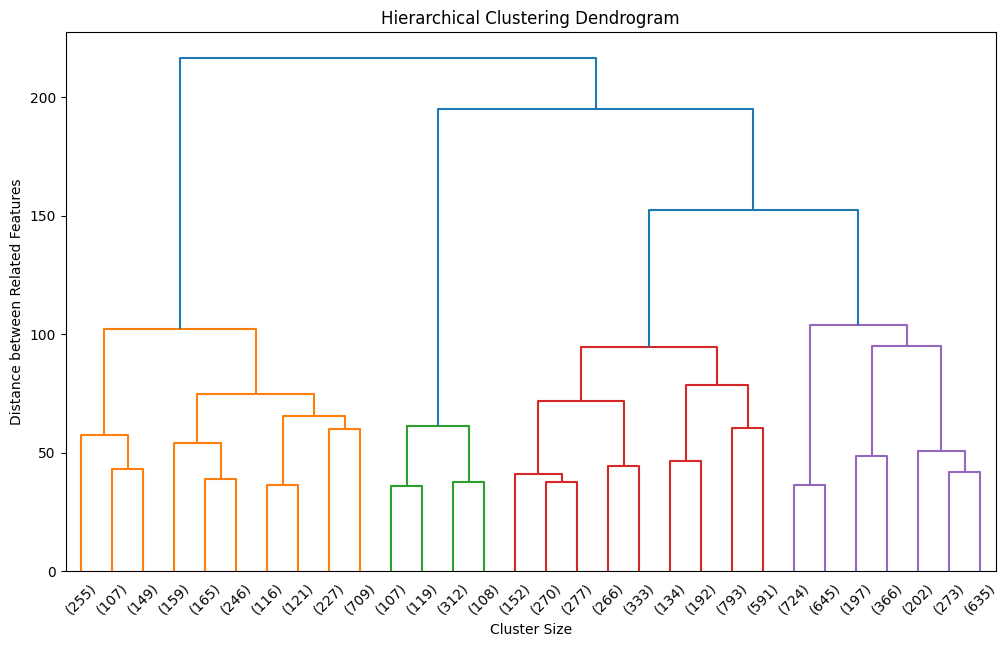

In [50]:
Z = linkage(cc_scaled, method='ward')

#We ttreat the 8,950 customers as their own tiny cluster, and then  looks for the two customers who similar based on their scaled features
#Ward  tidys the data by looking for the merger that keeps the new cluster as concentrated as possible
#This is repeated until everyone is part of one cluster

plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=30) # Showing the last 30 merges for clarity
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance between Related Features")
plt.show()

This dendrogram depicts the data into a tree format.  

The Vertical Axis represent the distance between the cluster points,The higher a horizontal bar is, the more different the two groups below it are. A tall vertical line means the groups are very distinct; a short line means they are quite similar.

The Numbers in Brackets on the horizontal axis e.g. 116, they tell you how many individual customers are within that specific branch.

The 4 colors depcit the 4 very distinct customer types whcih all the 8000 customers could be fit into.

#In Depth

---
The reason a dendrogram was used was to help figure out how many clusters we should have. The dendrogram answers this visually by helping us just look for the longest vertical lines that aren't crossed by a horizontal branch.

Looking at this dendrogram we can see that:

There are two main blue parent branches

The Left Blue Branch splits into the orange group

The Right Blue Branch splits into Green, Red, and Purple

This tells us that the customer base first splits into two major groups before being further clustered, specifically 4 clear and distinct clusters. Which then makes it easier for the model to decide how many clusters would be appropriate.

A key point to notice is that e the green branch in the middle. It has very few subbranches and was also merged after all the other branches. Represent our Outliers.



#Learning Models - K means  and PCA

---

In [51]:
elbow = []
for i in range(1, 11): #Essentially a trial and error loop
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10).fit(cc_scaled)
    elbow.append(kmeans.inertia_) #fter every trial run the model calculates how far the customers are from their cluster center


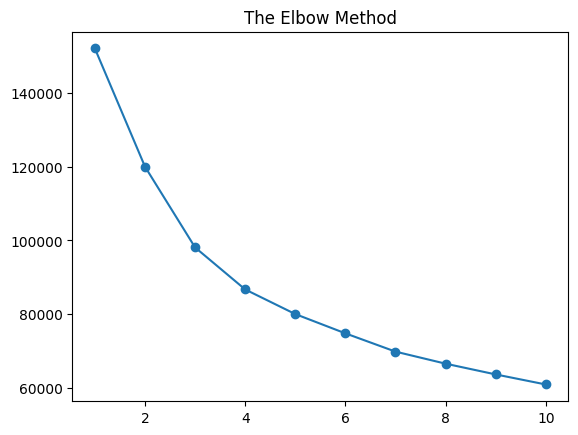

In [52]:
plt.plot(range(1, 11), wcss, marker='o') #wcss is the within cluster sum of square , the distance essentialy
plt.title('The Elbow Method')
plt.show()

In order for us to ensure that the optimal k mean value was selected we use the elbow method which is a mathematical calculation to calculate the appropriate number of groups.

The X axis represents the number of clusters we are testing and the Y axis the distance between cluster points.

The higher elbow line the bigger the difference between the people in the group and vice versa.

The Elbow is the little indentation in the line which represents the Point of best fit, its the point where adding another cluster will not help the cluster organisation.


# In depth

---
So looking at the grpah in detail we can notice :

The steep drop from  K=1 to K=3 informing us that customers are very diverse the drop from 1 group to 3 groups cleans up makes the groups much more consistent

Now,the elbow or dent in the line is visible at K = 4. After this point the line also starts to flatten out which helps identify K =4 as the optimal cluster number.

This perfectly matches the Dendrogram results which helps solidify our decision to make 4 clusters.

#Data Clustering


---

The model after having processed the data and calculated the optimal k means can draw a map of the different customer groups.



In [53]:
kmeans_model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10) #This is ehrre the model will cluster the dat ainto the 4 gorups by placing the 4 centoroids.
cc_df['Cluster'] = kmeans_model.fit_predict(cc_scaled)
#k-means++ is used otensure that the centeroids placed are not random, making the data grouping much nmore stable.

PCA

---

PCA is a dimensional reduction technique which simplifies and facilitates the visualisation of datasets by reducing the number of variables while retaining most of the original information.


In [54]:
pca = PCA(n_components=2)
cc_pca = pca.fit_transform(cc_scaled)
#The PCA aggregates 17 features and merges them into 2 key features PC1 and PC2, this technique flattens out all the data into a more visible and understandable format



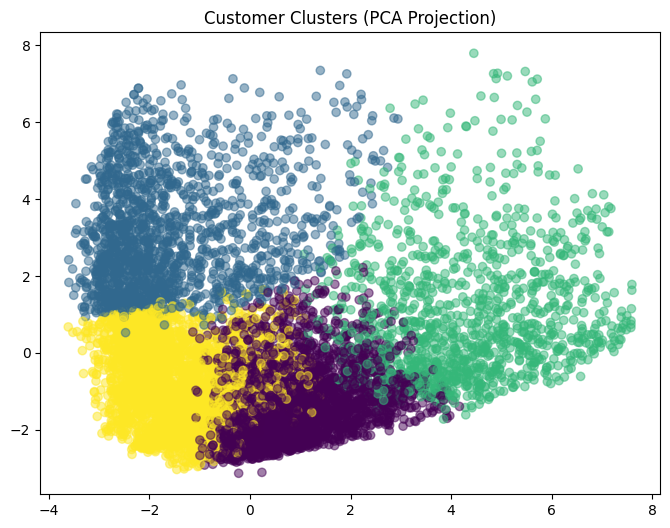

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(cc_pca[:, 0], cc_pca[:, 1], c=cc_df['Cluster'], cmap='viridis', alpha=0.5)
plt.title('Customer Clusters (PCA Projection)')
plt.show()

Now, this graph helps us determine the success of our data processing and mathematical calculations to determine the k means.  Firstly the 4 main colours are clearly group whilst also separated and not intertwined. This tells us that the model was able to calculate and identify clear boarders between the different types of customers

PC1 is represented by the x axis which represents the total volume. So, customers in the far right coloured in green are the big Spenders. Whilst on the far left, the customers in yellow are the low balance and inactive users

PC2 is represented by the y axis which represents the behaviour types

Now we can see that the yellow and purple clusters are very dense and tightly packed. The Green and Blue clusters are much looser and spread out

This graph helps us identify that low Spenders which are identifiable by Yellow and Purple are very predictable and like each other. Whilst the high spenders represented by green and blue have different habits from one another, making them harder to categorise.


# Evaluation

---



In [62]:
# We check if our 4 clusters are stable across the data
# We use the scaled data because clustering is based on distances
sil_score = silhouette_score(cc_scaled, cc_df['Cluster']) #this calculates the distance to same and different cluster points
print(f"Mean Silhouette Score for 4 Clusters: {sil_score:.4f}")

Mean Silhouette Score for 4 Clusters: 0.1942


The above code will help us get a numerical measure for how close cluster points are to one another and how far they are from different cluster points

Now, the way to read the score is +1 or anything close to this value means all the same clusters are tightly packed next to one another.

0 means the clusters are overlapping and the boundaries are not the clearest and -1 means error or the clustering did not work at all.

Now, our score of 0.19 is relatively common and good for unsupervised as it tells us that there is a real structure based on features to group people into, but due to the high diversity exactly fitting them into groups is not possible.




In [64]:
# Cluster Interpretation
cluster_summary = cc_df.groupby('Cluster').mean(numeric_only=True) #this gathers and groups all the customers into their respective cluster gorups via ID
#it the calculates each column and outputs the mean of the calculated mean of all the vlaues in that specific column (either 1,2,3 or 4 as per the 4 clusters)

In [59]:
# Here we pick the most descriptive columns to see the what makes uo=p each group
important_metrics = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

In [60]:
print("\n--- The 4 Customer Clusters (Averages) ---")
print(cluster_summary[important_metrics].T) # .T formats the clusters as columns


--- The 4 Customer Clusters (Averages) ---
Cluster                 0            1            2            3
BALANCE        630.306367  3567.467135  2116.864171   868.954651
PURCHASES      806.642179   346.865377  3102.471158   255.247659
CASH_ADVANCE   128.436715  2966.486206   509.363032   459.398185
CREDIT_LIMIT  3450.519429  6395.859595  7175.061224  3111.642762
PAYMENTS       931.100659  2369.282127  3351.479319   820.083004






 The above are the most important metrics, as they reveal a key trait of these customers.







* Balance shows us the customer's current debt to the bank.







* Purchases show as if the customers use the card







* cash advance, this tells us if customers are using the card at cashpoints, etc., which is a red flag due to the high interest rates which are brought along with these actions  







* credit_limit essentially tells us how much the bank thinks this person can work with responsibly







* payments simply tell us their responsibility in paying back their loans





Now, looking at these 4 groups , we can see that

Cluster 1 - individuals with lowest Balance and the lowest Cash Advance.This means they are the healthy customers who use the card normally.



Cluster 2 - individuals with high balance but very low purchases so they are the red flags who take out money resulting in high interest.



Cluster 3 - individuals with the highest purchases and the highest credit limit. so they are good high value customers trusted by the bank.



Clsuter 4 - individuals with the lowest purchases and the lowest credit limit, they are individuals whio barely touc hthe card or possibly new customers

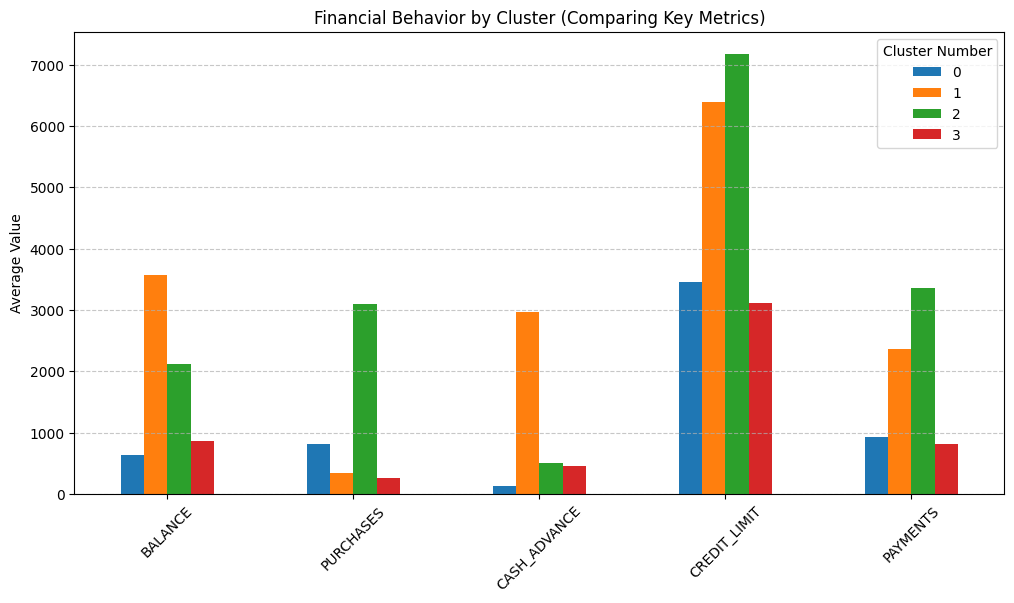

In [61]:
# Final isualiation of the cluster profile and all numerical values
cluster_summary[important_metrics].T.plot(kind='bar', figsize=(12, 6)) #this formats the data into organised bars
plt.title('Financial Behavior by Cluster (Comparing Key Metrics)')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title="Cluster Number") #this is what groups teh clsuter into their specific colour via ID
plt.grid(axis='y', linestyle='--', alpha=0.7) #adds horizontal marking to facilitate the reading of the graphs
plt.show()

So, to understand this graph , the x axis represents one of the 5 key financial metrics. Inside these groups, we have the 4 clusters, each depicted by a different colour. This allows us to see which cluster owns which financial behaviour or characteristics the most.





